# What Does a #1 Hit Actually Sound Like?
### A Data Analysis of Billboard Hot 100 Chart History and Spotify Audio Features

---

As a songwriter who has spent years trying to write songs that connect with people, I have always been curious about the DNA of hit songs. Is there some sweet spot between rhythm, energy, mood, and duration that more easily appeals to the average listener? Do the songs that top the charts share a sonic fingerprint that set them apart from the rest? Or is reaching the top due to other factors entirely, like luck, timing, marketing, or cultural impact?

To find out, I combined two datasets, one containing the complete history of the Billboard Hot 100 dating back to 1959, and the other containing Spotify audio feature data, to analyze the audio characteristics of every song that has ever reached #1.

**The data:**
- Billboard Hot 100 chart history (1959–present) via Kaggle
- Spotify Hit Predictor audio features dataset (1960–2019) via Kaggle
- 917 unique #1 hits analyzed after merging and cleaning

**The tools:**
- Python and pandas for data cleaning and analysis
- SQLite for data storage and querying
- Matplotlib and Seaborn for visualization
- Tableau Public for interactive dashboards

**What follows is a five part analysis exploring:**
1. What the average #1 hit sounds like
2. How much variation exists among #1 hits
3. How #1 hits compare to the rest of the Top 40
4. How the sound of a #1 hit has changed over six decades
5. Which audio features are correlated with each other

And at the end, I also included a few extra questions that aren't directly correlated to the main analysis, but that I thought would be fun to explore.

*Let's find out if there's a formula for a hit song.*

---

## Data Loading & Preparation

Before diving into the analysis, we need to load our two datasets, clean and 
standardize them, join them together, and store the result in a SQLite database.

**The two sources:**
- `hot100.csv` — Billboard Hot 100 chart history, one row per song per week
  - obtained from: https://www.kaggle.com/datasets/ludmin/billboard
- `dataset-of-[decade]s.csv` — Spotify audio features across six decades, combined into a single dataframe
  - obtained from: https://www.kaggle.com/datasets/theoverman/the-spotify-hit-predictor-dataset\

Songs are matched across the two datasets by name and artist after standardizing 
to lowercase. The resulting merged dataset contains 263,170 rows covering every 
charted week for every matched song, which is then stored in SQLite for querying 
throughout the analysis.

In [ ]:
# Import visualization libraries and set a global color scheme that will apply 
# to all charts throughout the notebook.

import matplotlib.pyplot as plt
import seaborn as sns

# Global style settings
BACKGROUND = "#1C1C1C"
ACCENT = "#68B2A0"
TEXT = "#FFFFFF"
SECONDARY = "#A8A8A8"

plt.rcParams.update({
    "figure.facecolor": BACKGROUND,
    "axes.facecolor": BACKGROUND,
    "axes.edgecolor": SECONDARY,
    "axes.labelcolor": TEXT,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "text.color": TEXT,
    "grid.color": "#2E2E2E",
    "grid.linestyle": "--",
    "font.family": "sans-serif",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
})

In [ ]:
# Load both datasets, standardize artist and song names to lowercase so they 
# match correctly, join them together on song and artist, and drop columns 
# we don't need for analysis.

import pandas as pd
import glob
import warnings
warnings.filterwarnings("ignore")

# Load all spotify decade CSVs at once
files = glob.glob("/Users/brenteaton/Documents/VS_code_projects/billboard_data_project/dataset-of-*.csv")
spotify_df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Load Billboard Data
billboard_df = pd.read_csv("/Users/brenteaton/Documents/VS_code_projects/billboard_data_project/hot100.csv")

# Standardize Billboard
billboard_df["Song"] = billboard_df["Song"].str.lower().str.strip()
billboard_df["Artist"] = billboard_df["Artist"].str.lower().str.strip()

# Standardize Spotify
spotify_df["track"] = spotify_df["track"].str.lower().str.strip()
spotify_df["artist"] = spotify_df["artist"].str.lower().str.strip()

# Create merged DataFrame on song and artist
merged_df = billboard_df.merge(
    spotify_df,
    left_on=["Song", "Artist"],
    right_on=["track", "artist"],
    how="inner",
)

# Drop extraneous columns
merged_df = merged_df.drop(columns=["uri", "track", "artist", "Image URL", "chorus_hit", "sections"])
print(merged_df.columns.tolist())


['Date', 'Song', 'Artist', 'Rank', 'Last Week', 'Peak Position', 'Weeks in Charts', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'target']


In [ ]:
# Saving merged DataFrame to SQLite

import sqlite3

conn = sqlite3.connect("/Users/brenteaton/Documents/VS_code_projects/billboard_data_project/billboard_spotify.db")

merged_df.to_sql("billboard_spotify", conn, if_exists="replace", index=False)

print("Saved to SQLite!")

Saved to SQLite!


In [ ]:
# Running a test query to ensure the data was saved correctly and is accessable.

conn = sqlite3.connect("/Users/brenteaton/Documents/VS_code_projects/billboard_data_project/billboard_spotify.db")

query = """
    SELECT Song, Artist, Rank, danceability, energy, valence, tempo
    FROM billboard_spotify
    LIMIT 10
"""
pd.read_sql_query(query, conn)

,Song,Artist,Rank,danceability,energy,valence,tempo
0,the ballad of thunder road,robert mitchum,95,0.661,0.632,0.953,129.407
1,the ballad of thunder road,robert mitchum,88,0.661,0.632,0.953,129.407
2,the ballad of thunder road,robert mitchum,99,0.661,0.632,0.953,129.407
3,the ballad of thunder road,robert mitchum,79,0.661,0.632,0.953,129.407
4,the ballad of thunder road,robert mitchum,77,0.661,0.632,0.953,129.407
5,the ballad of thunder road,robert mitchum,62,0.661,0.632,0.953,129.407
6,the ballad of thunder road,robert mitchum,74,0.661,0.632,0.953,129.407
7,the ballad of thunder road,robert mitchum,80,0.661,0.632,0.953,129.407
8,dreamy eyes,johnny tillotson,92,0.416,0.430,0.556,123.876
9,the ballad of thunder road,robert mitchum,88,0.661,0.632,0.953,129.407


---

## Analysis

With the data loaded, cleaned, and stored, we can now turn to the central 
question: **what does a #1 hit actually sound like?**

I broke this central questions into five smaller questions to make this analysis more approachable and thorough:
1. Baseline Profile - What are the average audio characteristics of a Billboard #1 hit?
2. Distribution - Are #1 hits consistent in their audio profile, or is there wide variation?
3. Comparison - Do #1 hits differ meaningfully in audio characteristics from the rest of the Top 40?
4. Trends Over Time - How has the sound of a #1 hit evolved across decades?
5. Feature Correlation - Which audio characteristics tend to move together in #1 hits?

A quick note on the Spotify audio features used throughout this analysis,
most are scored on a scale of 0 to 1:

| Feature | What it measures |
|---|---|
| **Danceability** | How suitable a track is for dancing |
| **Energy** | Perceptual intensity and activity |
| **Valence** | Musical positiveness — higher = happier |
| **Acousticness** | How acoustic vs. produced a song sounds |
| **Speechiness** | Presence of spoken word or rap |
| **Instrumentalness** | Likelihood of having no vocals |
| **Tempo** | Speed of the song in BPM |
| **Loudness** | Overall loudness in decibels (dB) |

This table is worth keeping as a reference throughout the analysis. With that, let's analyze some music.

## Question 1: Baseline Profile
*What are the average audio characteristics of a Billboard #1 hit?*

This is the big question, what does the average #1 hit actually sound like? If there is a formula for writing a hit, this is our best chance of finding it. Of course, we will need to test how truly representative the average is of the data by calculating the distribution (in question 2). But until then, lets find the average audio characteristics of a #1 hit.

My first approach is to pull all of the rows where Rank = 1 from our dataset and calculate the average of the audio features to create a baseline profile.



In [ ]:
# Query the average value of every audio feature across all weeks where a song 
# ranked #1. Note: songs with multiple weeks at #1 are counted multiple times here.

query = """
    SELECT 
        ROUND(AVG(danceability), 3) as avg_danceability,
        ROUND(AVG(energy), 3) as avg_energy,
        ROUND(AVG(valence), 3) as avg_valence,
        ROUND(AVG(tempo), 3) as avg_tempo,
        ROUND(AVG(loudness), 3) as avg_loudness,
        ROUND(AVG(acousticness), 3) as avg_acousticness,
        ROUND(AVG(speechiness), 3) as avg_speechiness,
        ROUND(AVG(instrumentalness), 3) as avg_instrumentalness,
        ROUND(AVG(duration_ms) / 60000, 2) as avg_duration_minutes
    FROM billboard_spotify
    WHERE Rank = 1
"""

baseline_df = pd.read_sql_query(query, conn)
print(baseline_df)

   avg_danceability  avg_energy  avg_valence  avg_tempo  avg_loudness  \
0             0.647       0.609         0.61    118.062        -8.173   

   avg_acousticness  avg_speechiness  avg_instrumentalness  \
0             0.271            0.071                 0.018   

   avg_duration_minutes  
0                  3.93  


### Methodology Note
Since songs with more weeks at #1 appear multiple times in the dataset, they weight the average of the baseline I re-ran the baseline deduplicating by song first so every #1 hit counts equally. This will show us a more true average, and will also reveal if songs that remain at #1 longer alter the averages significantly.

In [ ]:
# Same baseline query as above, but deduplicated so each song counts once 
# regardless of how many weeks it spent at #1. This is our canonical baseline.

query = """
    SELECT 
        ROUND(AVG(danceability), 3) as avg_danceability,
        ROUND(AVG(energy), 3) as avg_energy,
        ROUND(AVG(valence), 3) as avg_valence,
        ROUND(AVG(tempo), 3) as avg_tempo,
        ROUND(AVG(loudness), 3) as avg_loudness,
        ROUND(AVG(acousticness), 3) as avg_acousticness,
        ROUND(AVG(speechiness), 3) as avg_speechiness,
        ROUND(AVG(instrumentalness), 3) as avg_instrumentalness,
        ROUND(AVG(duration_ms) / 60000, 2) as avg_duration_minutes
    FROM (
        SELECT Song, Artist, AVG(danceability) as danceability,
               AVG(energy) as energy, AVG(valence) as valence,
               AVG(tempo) as tempo, AVG(loudness) as loudness,
               AVG(acousticness) as acousticness,
               AVG(speechiness) as speechiness,
               AVG(instrumentalness) as instrumentalness,
               AVG(duration_ms) as duration_ms
        FROM billboard_spotify
        WHERE Rank = 1
        GROUP BY Song, Artist
    )
"""

baseline_df = pd.read_sql_query(query, conn)
print(baseline_df)

   avg_danceability  avg_energy  avg_valence  avg_tempo  avg_loudness  \
0              0.63       0.602        0.615    118.019        -8.754   

   avg_acousticness  avg_speechiness  avg_instrumentalness  \
0             0.297            0.064                 0.023   

   avg_duration_minutes  
0                  3.88  


### Methodology Note
The two approaches produced nearly identical results, with no feature shifting 
by more than 0.05. This suggests that longer-charting #1 hits do not sound 
meaningfully different from shorter-charting ones, and that our baseline profile 
is robust regardless of counting method. All subsequent analysis will use the 
deduplicated version.

### Question 1 Finding

According to our data, the average Billboard #1 hit looks like this:
- **Danceability: 0.630** — moderately danceable, not a pure dance track
- **Energy: 0.602** — medium-high energy
- **Valence: 0.615** — slightly positive/happy sounding
- **Tempo: 118 BPM** — solidly mid-tempo
- **Loudness: -8.754 dB** — moderately loud
- **Acousticness: 0.297** — mostly produced, not acoustic
- **Speechiness: 0.064** — almost entirely sung, minimal rap or spoken word
- **Instrumentalness: 0.023** — almost always has vocals
- **Duration: 3.88 minutes** — classic radio-friendly length

Using this information, I should be writing mid tempo, slightly happy and moderately danceable songs just under four minutes to top the charts. But before I pick up the pen, I need to dig into this data a little more to find out how reliable this is. Do most hit songs really sound like this, or is this average just a midpoint between songs that are all over the place? Lets find out.

So maybe the formula for a #1 hit is a mid tempo, slightly happy, and moderatley danceable song just under four minutes. That seems pretty reasonable, but I am not sure if I trust that most #1 hits actually sound like this. The average tells us the center of the data points, but it doesnt tell us how close most of the data points are to that center. For that we need to calculate the distribution.

## Question 2: Distribution
*Are #1 hits consistent in their audio profile, or is there wide variation?*

We have found the average audio characteristics of a #1 hit, but averages can be misleading. In order to determine whether our averages can truly be considered to be a formula for a number #1 hit, we need to take a deeper look into the distribution within each average to understand whether the "sound" of a #1 hit is consistent or highly variable.

In [ ]:
# Pull one row per unique #1 hit with all audio features averaged across its 
# chart weeks. This becomes our primary working dataframe for Questions 2-5.

query = """
    SELECT Song, Artist, danceability, energy, valence, 
           tempo, loudness, acousticness, speechiness, instrumentalness, 
           ROUND(duration_ms / 60000, 2) as duration_minutes
    FROM (
        SELECT Song, Artist, AVG(danceability) as danceability,
               AVG(energy) as energy, AVG(valence) as valence,
               AVG(tempo) as tempo, AVG(loudness) as loudness,
               AVG(acousticness) as acousticness,
               AVG(speechiness) as speechiness,
               AVG(instrumentalness) as instrumentalness,
               AVG(duration_ms) as duration_ms
        FROM billboard_spotify
        WHERE Rank = 1
        GROUP BY Song, Artist
    )
"""

number_ones_df = pd.read_sql_query(query, conn)
number_ones_df.describe()

,danceability,energy,valence,tempo,loudness,acousticness,speechiness,instrumentalness,duration_minutes
count,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000
mean,0.629626,0.601984,0.615034,118.019434,-8.753783,0.297289,0.064187,0.023480,3.880840
std,0.151410,0.193495,0.247689,26.002389,3.396631,0.272367,0.067949,0.117396,0.937825
min,0.149000,0.026400,0.056200,61.084000,-21.861000,0.000049,0.023200,0.000000,1.650000
25%,0.533000,0.464000,0.421000,99.905000,-11.015000,0.065700,0.031500,0.000000,3.320000
50%,0.643000,0.607000,0.649000,116.112000,-8.340000,0.202000,0.040300,0.000005,3.820000
75%,0.740000,0.745000,0.826000,131.846000,-6.160000,0.490000,0.062900,0.000376,4.380000
max,0.979000,0.989000,0.985000,210.186000,-0.810000,0.994000,0.576000,0.929000,8.440000


## Finding: There is no consistent formula for a #1 hit

As it turns out, the "sound" of a #1 hit is highly variable. Examining the distribution of audio features across 917 unique #1 hits, the only characteristics with minimal variance are speechiness and instrumentalness. This means that #1 hits are almost always sung with vocals, and rarely instrumental, but otherwise are highly variable in their profile. The most variable features are valence (mood) and acousticness, which makes sense given that the data spans six decades of popular music.

That is sort of a bummer, but also kind of a relief. The fact that there isn't a clean cut formular for a #1 hit suggests that there is more artistry and craft in writing a song that connects broadly with people, rather that just following a cookie cutter approach. While we have sort of disproven the existence of such a formula, I am still interested to see how the audio profile of #1 hits compare to other groups of songs, and if / how they have changed over time. 


### Methodology Note
Loudness, tempo, and duration are normalized to a 0–1 scale for visual 
comparability. Instrumentalness is excluded from this chart as it is 
effectively zero across nearly all #1 hits, adding no visual information — 
see Question 2 findings for details.

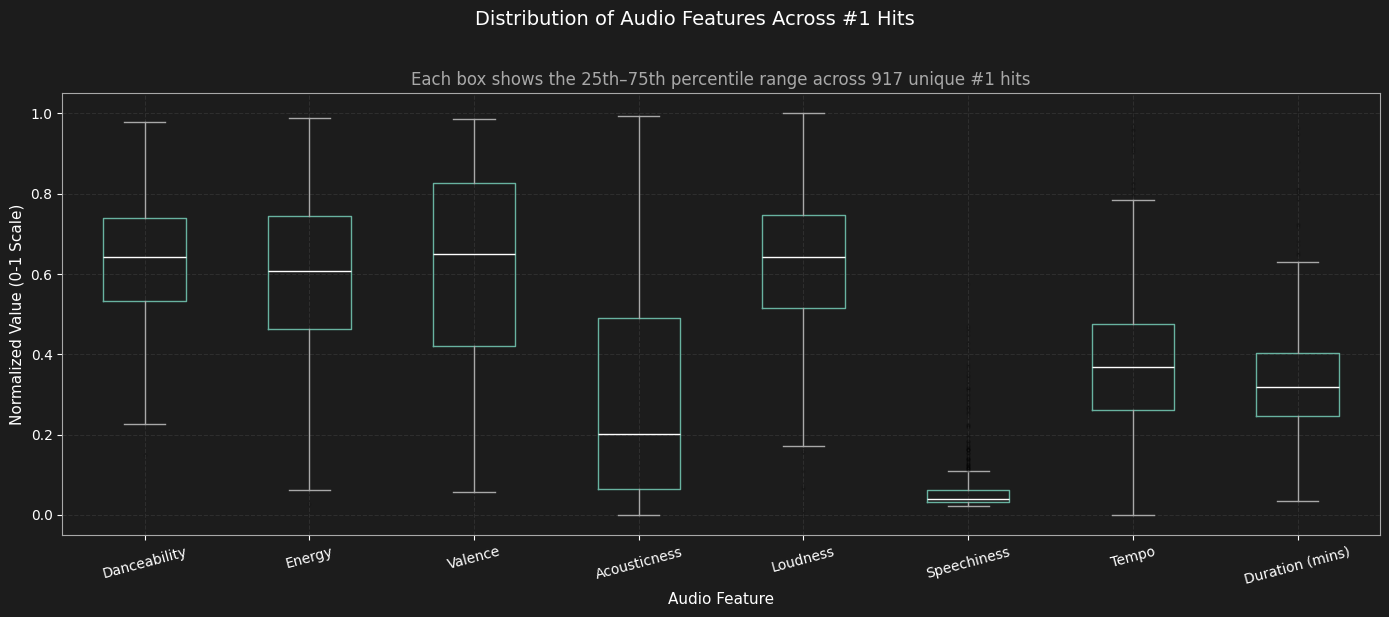

In [ ]:
# Boxplot showing the distribution of each audio feature across all 917 unique 
# #1 hits. Loudness, tempo, and duration are normalized to 0-1 for comparability.

features = ["danceability", "energy", "valence", "acousticness", 
            "loudness", "speechiness", "tempo", "duration_minutes"]

plot_df = number_ones_df[features].copy()

# Normalize features that aren't already on 0-1 scale
for col in ["loudness", "tempo", "duration_minutes"]:
    plot_df[col] = (plot_df[col] - plot_df[col].min()) / (plot_df[col].max() - plot_df[col].min())

fig, ax = plt.subplots(figsize=(14, 6))

plot_df.boxplot(
    ax=ax,
    color=dict(boxes=ACCENT, whiskers=SECONDARY, medians=TEXT, caps=SECONDARY),
    flierprops=dict(marker="o", color=ACCENT, alpha=0.1, markersize=2)  # reduced outlier visibility
)

ax.set_xticklabels(["Danceability", "Energy", "Valence", "Acousticness", 
                     "Loudness", "Speechiness", "Tempo", "Duration (mins)"])  # clean labels

fig.suptitle("Distribution of Audio Features Across #1 Hits", 
             fontsize=14, y=1.02)
ax.set_title("Each box shows the 25th–75th percentile range across 917 unique #1 hits", 
             fontsize=12, color=SECONDARY)

ax.set_xlabel("Audio Feature")
ax.set_ylabel("Normalized Value (0-1 Scale)")
ax.set_facecolor(BACKGROUND)
fig.patch.set_facecolor(BACKGROUND)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Question 3: Comparison
*Do #1 hits differ meaningfully in audio characteristics from the rest of the Top 40?*

We now know the average audio characteristics of a #1 hit, and that they are highly variable for the most part. But how does that compare to the rest of the top 40? Is there anything that sets a #1 hits apart from songs that peaked at #5, or #32? May we still be able to find some key to writing songs that can top the charts? Here we compare the audio profile of #1 hits against all other Top 40 songs to see whether reaching the top spot is associated with any distinct sonic characteristics, or whether #1 hits are largely indistinguishable from the pack.


### Methodology Note
*Note: a one song discrepancy exists between queries due to a data ambiguity 
in peak position recording. This does not materially affect any findings.*

In [ ]:
# Compare average audio features between #1 hits and all other Top 40 hits 
# to see if songs that reached #1 are sonically distinct from the rest of the pack.

query = """
    SELECT 
        group_label,
        COUNT(*) as song_count,
        ROUND(AVG(danceability), 3) as avg_danceability,
        ROUND(AVG(energy), 3) as avg_energy,
        ROUND(AVG(valence), 3) as avg_valence,
        ROUND(AVG(tempo), 3) as avg_tempo,
        ROUND(AVG(loudness), 3) as avg_loudness,
        ROUND(AVG(acousticness), 3) as avg_acousticness,
        ROUND(AVG(speechiness), 3) as avg_speechiness,
        ROUND(AVG(instrumentalness), 3) as avg_instrumentalness,
        ROUND(AVG(duration_ms) / 60000, 2) as avg_duration_minutes
    FROM (
        SELECT Song, Artist,
               CASE WHEN MIN("Peak Position") = 1 THEN '#1 Hit' ELSE 'Top 40' END as group_label,
               AVG(danceability) as danceability,
               AVG(energy) as energy, AVG(valence) as valence,
               AVG(tempo) as tempo, AVG(loudness) as loudness,
               AVG(acousticness) as acousticness,
               AVG(speechiness) as speechiness,
               AVG(instrumentalness) as instrumentalness,
               AVG(duration_ms) as duration_ms
        FROM billboard_spotify
        WHERE "Peak Position" <= 40
        GROUP BY Song, Artist
    )
    GROUP BY group_label
"""

comparison_df = pd.read_sql_query(query, conn)
print(comparison_df)

  group_label  song_count  avg_danceability  avg_energy  avg_valence  \
0      #1 Hit         918             0.630       0.602        0.615   
1      Top 40        9252             0.603       0.621        0.612   

   avg_tempo  avg_loudness  avg_acousticness  avg_speechiness  \
0    118.033        -8.749             0.297            0.064   
1    120.246        -8.696             0.281            0.067   

   avg_instrumentalness  avg_duration_minutes  
0                 0.023                  3.88  
1                 0.027                  3.78  


## Finding: There is no meaningful difference between the audio features of a #1 Hit and a Top 40 Hit

Examining the average audio features of 918 #1 hits against 10,124 Top 40 hits, the two groups are nearly indentical across every characteristic, with no feature differing by more than 0.02. This means that there is no meaningful difference in audio characteristics between songs that reach #1 and all other top 40 hits, and that audio features alone cannot be used to predict if a song will go #1. 

This even further solidifies that there is not a formula for writing a #1 hit. We are however taking averages of songs over 60 years, which include many major shifts in culture and technology, and could be the reason for the high variance in our data. Maybe looking at how #1 hits have changed over time will reveal something interesting, and even possibly show to the direction they are moving in.


## Question 4: Trends Over Time
*How has the sound of a #1 hit evolved across decades?*

Our baseline profile tells us what a #1 hit sounds like on average across all time, but popular music changes drastically with the ebbs and flows of culture and the development of new technology. We found that there is a high amount of variance among songs that have hit #1, but that may be because we are taking the average of songs that span over 60 years. Here we break down the audio characteristics of #1 hits by year to see if and how the "sound of success" has changed over time.


### Methodology Note
For this analysis, songs are counted once per year in which they reached #1, 
rather than once overall. This means a small number of songs (primarily 
recurring Christmas hits) appear in multiple years. This is intentional
for a trends over time analysis, what matters is what was hitting #1 in a 
given year, not unique songs overall. This accounts for the slightly higher 
song count (958) compared to previous questions (918).

### Methodology Note
This analysis is limited to 1959–2019 as the Spotify audio features dataset 
does not have complete coverage beyond 2019. Including later years would 
produce unreliable averages based on very few songs.

In [ ]:
# Pull one row per unique #1 hit per year with averaged audio features, limited 
# to 1959-2019 where Spotify data coverage is reliable.

query = """
    SELECT 
        CAST(SUBSTR(Date, 1, 4) AS INTEGER) as year,
        Song, Artist,
        AVG(danceability) as danceability,
        AVG(energy) as energy,
        AVG(valence) as valence,
        AVG(tempo) as tempo,
        AVG(loudness) as loudness,
        AVG(acousticness) as acousticness,
        AVG(speechiness) as speechiness,
        AVG(instrumentalness) as instrumentalness,
        AVG(duration_ms) / 60000 as duration_minutes
    FROM billboard_spotify
    WHERE Rank = 1
    AND CAST(SUBSTR(Date, 1, 4) AS INTEGER) <= 2019
    GROUP BY year, Song, Artist
    ORDER BY year
"""

trends_df = pd.read_sql_query(query, conn)
print(trends_df.shape)

(958, 12)


### Full Feature Trends
Now we look at all audio features across all years to get a complete picture 
of how the sound of a #1 hit has evolved over time.

In [ ]:
# Calculate the mean of every audio feature by year across all #1 hits, 
# printed in full without truncation to see the complete 1959-2019 picture.

trends_summary = trends_df.groupby("year")[["danceability", "energy", "valence", 
                                             "tempo", "loudness", "acousticness",
                                             "speechiness", "instrumentalness", 
                                             "duration_minutes"]].mean().round(3)

print(trends_summary.to_string())

      danceability  energy  valence    tempo  loudness  acousticness  speechiness  instrumentalness  duration_minutes
year                                                                                                                 
1959         0.538   0.415    0.590  111.338   -11.597         0.747        0.050             0.000             2.900
1960         0.559   0.460    0.645  113.496   -10.206         0.718        0.039             0.000             2.987
1961         0.586   0.529    0.766  111.791    -9.494         0.594        0.058             0.055             2.494
1962         0.464   0.509    0.646  111.460    -9.587         0.612        0.066             0.079             2.838
1963         0.523   0.549    0.677  119.129    -9.842         0.612        0.051             0.061             2.533
1964         0.508   0.577    0.670  120.822    -8.752         0.524        0.061             0.053             2.695
1965         0.572   0.598    0.718  116.063    -9.618  

## Finding: The sound of a #1 hit has changed dramatically since 1959

Examining average audio features by year from 1959 to 2019, several clear 
long-term trends emerge:

**Songs have gotten louder and more energetic.** Loudness increased from -11.6 dB 
in 1959 to -4.7 dB in 2009, and energy rose from 0.415 to a peak of 0.794 in 2010, reflecting the shift from live acoustic performance to heavily produced, 
electronically amplified music.

**Songs have gotten darker.** Valence (mood) declined steadily from 0.590 in 1959 
to 0.440 in 2018, meaning #1 hits have become significantly more melancholy over 
time, even as they became more energetic and danceable.

**Songs have gotten less acoustic and more danceable.** Acousticness dropped 
dramatically from 0.747 in 1959 to near zero by the late 2000s, while danceability 
climbed from 0.538 to a peak of 0.759 in 2017.

**The rise of hip-hop is visible in the data.** Speechiness (a measure of spoken 
word content) nearly quadrupled from 0.050 in 1959 to 0.191 in 2003, tracking 
the cultural rise of rap and hip-hop on the charts.

**Songs got longer, then shorter again.** Average duration peaked at 5.1 minutes 
in 1979 before gradually declining to 3.2 minutes by 2019, a pattern consistent 
with the influence of streaming platforms rewarding shorter songs.

So it seems a large part of the distribution variance in our baseline profile of #1 hits is due to the data being dispersed over such a large period of time, and likely influenced by factors not present in our data set. While this insight doesn't necessarily reserect the possibility of a formula for #1 hits, it does provide narrower windows to describe what is popular in music during specific timespans.

In [ ]:
# Build a summary dataframe with mean, 25th percentile, and 75th percentile 
# for each audio feature by year — used to draw the trend lines and shaded 
# bands in the visualization below.

trend_features = ["danceability", "energy", "valence", "acousticness", 
                  "loudness", "speechiness", "tempo", "duration_minutes"]

trend_stats = trends_df.groupby("year")[trend_features].agg(
    ["mean", lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]
).round(3)

trend_stats.columns = ["_".join([col, fn]) for col, fn in trend_stats.columns]
trend_stats = trend_stats.rename(columns=lambda x: x.replace("<lambda_0>", "p25").replace("<lambda_1>", "p75"))

print(trend_stats.head())

      danceability_mean  danceability_p25  danceability_p75  energy_mean  \
year                                                                       
1959              0.538             0.520             0.578        0.415   
1960              0.559             0.507             0.636        0.460   
1961              0.586             0.491             0.741        0.529   
1962              0.464             0.330             0.548        0.509   
1963              0.523             0.417             0.647        0.549   

      energy_p25  energy_p75  valence_mean  valence_p25  valence_p75  \
year                                                                   
1959       0.375       0.518         0.590        0.494        0.732   
1960       0.296       0.589         0.645        0.373        0.861   
1961       0.430       0.609         0.766        0.598        0.949   
1962       0.307       0.660         0.646        0.524        0.810   
1963       0.349       0.735       

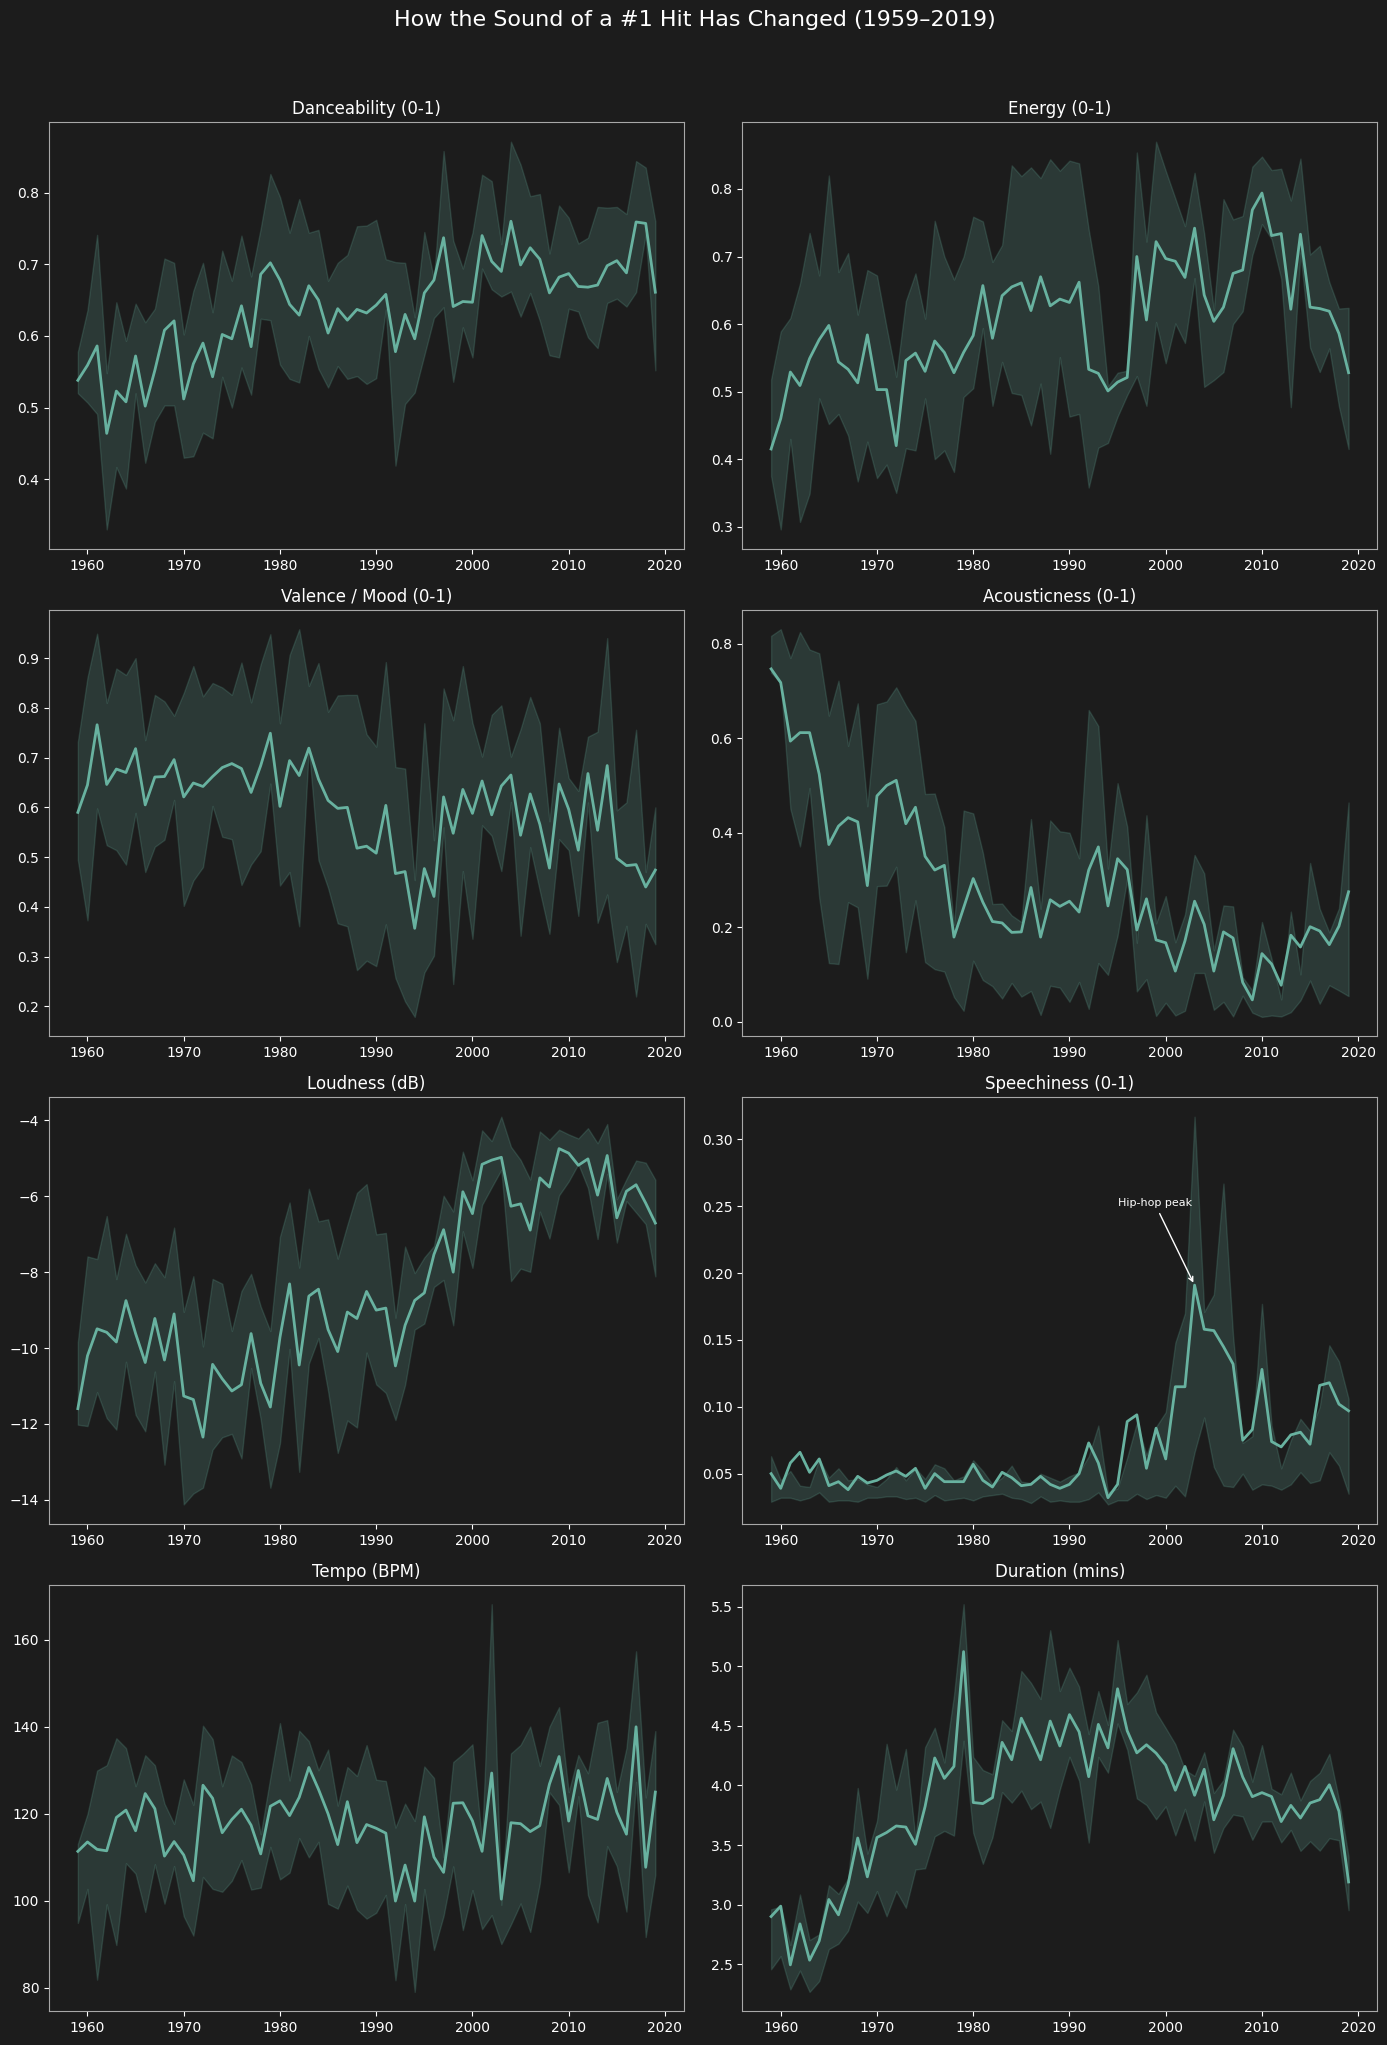

In [ ]:
# Grid of 8 trend charts showing how each audio feature has changed from 1959 
# to 2019. The shaded band shows the 25th-75th percentile range and the line 
# shows the annual mean. Includes an annotation marking the hip-hop peak in speechiness.

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

feature_labels = {
    "danceability": "Danceability (0-1)",
    "energy": "Energy (0-1)",
    "valence": "Valence / Mood (0-1)",
    "acousticness": "Acousticness (0-1)",
    "loudness": "Loudness (dB)",
    "speechiness": "Speechiness (0-1)",
    "tempo": "Tempo (BPM)",
    "duration_minutes": "Duration (mins)"
}

years = trend_stats.index

for i, feature in enumerate(trend_features):
    ax = axes[i]
    
    mean = trend_stats[f"{feature}_mean"]
    p25 = trend_stats[f"{feature}_p25"]
    p75 = trend_stats[f"{feature}_p75"]
    
    # Shaded band between 25th and 75th percentile
    ax.fill_between(years, p25, p75, alpha=0.2, color=ACCENT)
    
    # Mean trend line
    ax.plot(years, mean, color=ACCENT, linewidth=2)

    # Annotation for speechiness spike
    if feature == "speechiness":
        ax.annotate("Hip-hop peak", 
                    xy=(2003, trend_stats["speechiness_mean"][2003]),
                    xytext=(1995, 0.25),
                    color=TEXT,
                    fontsize=8,
                    arrowprops=dict(arrowstyle="->", color=TEXT, lw=1))
    
    ax.set_title(feature_labels[feature], fontsize=12)
    ax.set_facecolor(BACKGROUND)
    ax.tick_params(colors=TEXT)
    for spine in ax.spines.values():
        spine.set_edgecolor(SECONDARY)

fig.suptitle("How the Sound of a #1 Hit Has Changed (1959–2019)", 
             fontsize=16, y=1.02)
fig.patch.set_facecolor(BACKGROUND)
plt.tight_layout()
plt.show()

*The bold line represents the average value for each year. The shaded band 
represents the range between the 25th and 75th percentile of all #1 hits in 
that year, giving a sense of how much variation existed alongside the average trend.*

## Question 5: Feature Correlation
*Which audio characteristics tend to move together in #1 hits?*

We have discovered that #1 hits can vary widely between different audio characteristics, but we havent really tested to see if there are consistent relationships between those audio characteristics. Maybe there are certain ratios between noise level and accousticness, or speechiness and duration, that appeal to the average listener. Here we conduct a correlation analysis, which reveals which features tend to increase and decrease togetherm and which move in opposite directions. This will give us a deeper understanding of the underlysing structure of a #1 hit, and may reveal some guidlines for attempting to write songs with mass appeal.

In [ ]:
# Calculate the correlation matrix for all audio features across #1 hits — 
# reveals which features tend to move together and which move in opposite directions.

number_ones_corr = number_ones_df[["danceability", "energy", "valence", 
                                    "tempo", "loudness", "acousticness",
                                    "speechiness", "instrumentalness",
                                    "duration_minutes"]].corr().round(3)

print(number_ones_corr)

                  danceability  energy  valence  tempo  loudness  \
danceability             1.000   0.278    0.424 -0.155     0.215   
energy                   0.278   1.000    0.470  0.120     0.664   
valence                  0.424   0.470    1.000  0.044     0.126   
tempo                   -0.155   0.120    0.044  1.000     0.031   
loudness                 0.215   0.664    0.126  0.031     1.000   
acousticness            -0.359  -0.561   -0.237 -0.104    -0.395   
speechiness              0.214   0.182    0.085  0.047     0.211   
instrumentalness         0.004   0.003    0.026 -0.031    -0.105   
duration_minutes         0.101   0.060   -0.182  0.024    -0.009   

                  acousticness  speechiness  instrumentalness  \
danceability            -0.359        0.214             0.004   
energy                  -0.561        0.182             0.003   
valence                 -0.237        0.085             0.026   
tempo                   -0.104        0.047            -0.0

## Finding: Several Audio Features Have Strong Correlations

Examining the correlation matrix reveals interesting positive and negative relationships between audio features:

**Strong positive correlations (move together):**

**Energy & Loudness: 0.664** — the strongest relationship in the whole matrix. Louder songs are more energetic, which makes intuitive sense.

**Energy & Valence: 0.470** — more energetic songs tend to be happier.

**Danceability & Valence: 0.424** — more danceable songs tend to be happier too.

**Strong negative correlations (move opposite):**

**Energy & Acousticness: -0.561** — the more acoustic a song, the less energetic. Makes total sense — think acoustic ballad vs electronic dance track.

**Acousticness & Loudness: -0.395** — acoustic songs tend to be quieter.

**Acousticness & Danceability: -0.359** — acoustic songs are less danceable.

**Notably weak correlations:**

**Tempo has almost no relationship with anything** — fast songs aren't necessarily more energetic, danceable, or happy. Tempo is essentially independent.

**Instrumentalness is near zero across the board** — makes sense given almost all #1 hits have vocals.


So there isn't a clear cut formula for writing a hit song, but here we uncover some useful guidlines that expose what is more likely to appeal to listeners. If I wanted to make an acoustic hit, making it quiter, softer, and less danceable will be more likely to connect with a wide audience. Most of these make intuitive sense, but it is interesting to see them layed out.

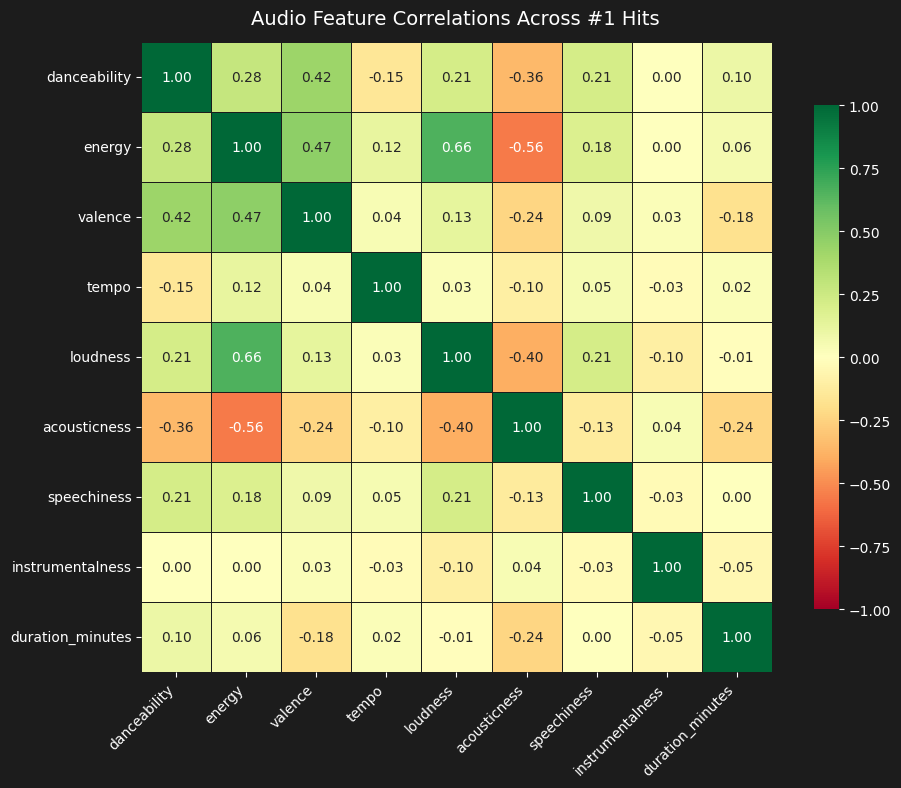

In [ ]:
# Heatmap visualization of the correlation matrix. Green = strong positive 
# correlation, red = strong negative correlation, yellow = little to no relationship.

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    number_ones_corr,
    ax=ax,
    cmap="RdYlGn",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor=BACKGROUND,
    square=True,
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"shrink": 0.8}
)

fig.suptitle("Audio Feature Correlations Across #1 Hits", fontsize=14)
ax.set_facecolor(BACKGROUND)
fig.patch.set_facecolor(BACKGROUND)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Conclusion: So, What Does a #1 Hit Actually Sound Like?

After analyzing 917 unique Billboard #1 hits from 1959 to 2019 across nine 
audio dimensions, a few things become clear.

On average, a #1 hit is moderately danceable, medium-high energy, slightly 
positive in mood, and clocks in at just under four minutes. It is almost always 
sung, not spoken or instrumental, and heavily produced rather than acoustic. 
But averages only tell part of the story.

The more interesting finding is that there is no consistent formula for a #1 
hit. Mood, acousticness, and energy all vary wildly across the 917 songs in 
this dataset, meaning a melancholy ballad and a high-energy dance track have 
an equal shot at the top spot. The only thing almost every #1 hit has in common 
is that someone is singing.

What has changed dramatically is the *sound of success over time*. Since 1959, 
#1 hits have gotten louder, more energetic, more danceable, and less acoustic 
reflecting the broader shift from live acoustic performance to electronically 
produced music. At the same time, they have gotten darker in mood, a trend 
that runs counter to the assumption that popular music is happy music.

Perhaps most surprisingly, a #1 hit sounds almost identical to any other Top 40 
hit on an audio level. The data suggests that what separates a #1 from a #32 
is not the sound of the song, but something esle entirely.

In short: there is no magic formula. But if you had to write one, it would 
probably be a four-minute, high-energy, danceable song with a great vocal 
performance — and if you're making it today, it should probably sound at least 
a little sad.

---

## While we're here...
While we're here with this data in front of us, let's have a little fun. As a 
musician myself, I had several questions pop into my head while performing this 
analysis:

1. What are the #1 hits at the extremes of each audio characteristic — the shortest 
and longest, the happiest and saddest? And are there any #1 hits without vocals?
2. Is there a "most average" #1 hit? A song that has reached #1 and closely matches 
the average audio profile we uncovered?
3. Which artists have spent the most total weeks in the Top 40?

In [ ]:
# Find the #1 hits at the extremes of each audio feature — the most and least 
# danceable, energetic, happy, fast, acoustic, and shortest and longest songs 
# to ever reach #1.

query = """
    SELECT Song, Artist,
           ROUND(danceability, 3) as danceability,
           ROUND(energy, 3) as energy,
           ROUND(valence, 3) as valence,
           ROUND(tempo, 3) as tempo,
           ROUND(acousticness, 3) as acousticness,
           ROUND(speechiness, 3) as speechiness,
           ROUND(instrumentalness, 3) as instrumentalness,
           ROUND(duration_ms / 60000, 2) as duration_minutes
    FROM (
        SELECT Song, Artist,
               AVG(danceability) as danceability,
               AVG(energy) as energy,
               AVG(valence) as valence,
               AVG(tempo) as tempo,
               AVG(acousticness) as acousticness,
               AVG(speechiness) as speechiness,
               AVG(instrumentalness) as instrumentalness,
               AVG(duration_ms) as duration_ms
        FROM billboard_spotify
        WHERE Rank = 1
        GROUP BY Song, Artist
    )
"""

number_ones_full_df = pd.read_sql_query(query, conn)

# Most and least for each feature
features = {
    "danceability": "Danceability",
    "energy": "Energy",
    "valence": "Valence (Mood)",
    "tempo": "Tempo (BPM)",
    "acousticness": "Acousticness",
    "duration_minutes": "Duration"
}

for col, label in features.items():
    most = number_ones_full_df.loc[number_ones_full_df[col].idxmax(), ["Song", "Artist", col]]
    least = number_ones_full_df.loc[number_ones_full_df[col].idxmin(), ["Song", "Artist", col]]
    print(f"\n{label}:")
    print(f"  Most:  {most['Song']} — {most['Artist']} ({most[col]})")
    print(f"  Least: {least['Song']} — {least['Artist']} ({least[col]})")


Danceability:
  Most:  ice ice baby — vanilla ice (0.979)
  Least: bridge over troubled water — simon & garfunkel (0.149)

Energy:
  Most:  when doves cry — prince (0.989)
  Least: the first time ever i saw your face — roberta flack (0.026)

Valence (Mood):
  Most:  what a fool believes — the doobie brothers (0.985)
  Least: hello — lionel richie (0.056)

Tempo (BPM):
  Most:  i'm leaving it up to you — dale & grace (210.186)
  Least: hello — lionel richie (61.084)

Acousticness:
  Most:  you're beautiful — james blunt (0.994)
  Least: house of the rising sun — the animals (0.0)

Duration:
  Most:  money for nothing — dire straits (8.44)
  Least: stay — maurice williams & the zodiacs (1.65)


In [ ]:
# Filter for #1 hits with an instrumentalness score above 0.5 — Spotify's 
# threshold for classifying a song as likely instrumental — to see if any 
# purely instrumental songs have ever reached #1.

query = """
    SELECT Song, Artist, 
           ROUND(AVG(instrumentalness), 3) as instrumentalness
    FROM billboard_spotify
    WHERE Rank = 1
    GROUP BY Song, Artist
    HAVING AVG(instrumentalness) > 0.5
    ORDER BY instrumentalness DESC
"""

instrumentals_df = pd.read_sql_query(query, conn)
print(instrumentals_df)

                                Song  \
0                            telstar   
1                   you're beautiful   
2                  afternoon delight   
3                           calcutta   
4                   miami vice theme   
5                     i'm a believer   
6                theme from s.w.a.t.   
7                  can't buy me love   
8                               rise   
9               grazing in the grass   
10                     gonna fly now   
11      star wars theme/cantina band   
12         chariots of fire - titles   
13                             venus   
14              a fifth of beethoven   
15                   justify my love   
16  whatever gets you thru the night   
17               get off of my cloud   

                                           Artist  instrumentalness  
0                                   the tornadoes             0.929  
1                                     james blunt             0.928  
2                            

### Extra 1: The Extremes — #1 Hits at the Edge of Every Audio Characteristic

Every average hides outliers. Here are the #1 hits that sit at the extremes 
of each audio feature:

- **Most danceable:** "Ice Ice Baby" — Vanilla Ice (0.979)
- **Least danceable:** "Bridge Over Troubled Water" — Simon & Garfunkel (0.149)
- **Most energetic:** "When Doves Cry" — Prince (0.989)
- **Least energetic:** "The First Time Ever I Saw Your Face" — Roberta Flack (0.026)
- **Happiest:** "What a Fool Believes" — The Doobie Brothers (0.985)
- **Saddest:** "Hello" — Lionel Richie (0.056)
- **Fastest:** "I'm Leaving It Up to You" — Dale & Grace (210 BPM)
- **Slowest:** "Hello" — Lionel Richie (61 BPM) *(yes, Hello appears twice)*
- **Most acoustic:** "You're Beautiful" — James Blunt (0.994)
- **Least acoustic:** "House of the Rising Sun" — The Animals (0.000) *clearly an error*
- **Longest:** "Money for Nothing" — Dire Straits (8:44)
- **Shortest:** "Stay" — Maurice Williams & The Zodiacs (1:39) 

"Hello" by Lionel Richie claiming both the saddest and slowest title feels 
about right. And "Stay" at just 1 minute and 39 seconds remains one of the 
shortest songs to ever hit #1 — proof that you don't need much time to make 
an impression.

---

### Bonus: Are There Any Instrumental #1 Hits?

Spotify classifies songs with an instrumentalness score above 0.5 as likely 
instrumental. Filtering for #1 hits above that threshold reveals some genuine 
classics — Telstar by The Tornadoes, the Miami Vice Theme, Chariots of Fire 
by Vangelis, and the Rocky theme among them — confirming that yes, a small 
handful of purely instrumental songs have reached the top of the Billboard 
Hot 100.

Worth noting: a few songs in this list clearly have vocals (Can't Buy Me Love 
by The Beatles, I'm a Believer by The Monkees) — a reminder that even Spotify's 
own audio classification isn't perfect, and that real world data always requires 
a critical eye.

In [ ]:
# Calculate the Euclidean distance between each #1 hit and the average audio 
# profile established in Question 1 to find the most mathematically "average" 
# #1 hit — the song that sounds most like a typical #1 hit across all features.

avg_profile = {
    "danceability": 0.630,
    "energy": 0.602,
    "valence": 0.615,
    "tempo": 118.019,
    "loudness": -8.754,
    "acousticness": 0.297,
    "speechiness": 0.064,
    "instrumentalness": 0.023,
    "duration_minutes": 3.88
}

features = list(avg_profile.keys())

scaler = MinMaxScaler()
scaled = scaler.fit_transform(number_ones_df[features])
scaled_df = pd.DataFrame(scaled, columns=features)

avg_scaled = scaler.transform([list(avg_profile.values())])

distances = np.sqrt(((scaled_df - avg_scaled) ** 2).sum(axis=1))
number_ones_df["distance_from_avg"] = distances

most_average = number_ones_df.loc[distances.idxmin()]
print(most_average[["Song", "Artist", "danceability", "energy", 
                     "valence", "tempo", "loudness", "acousticness",
                     "speechiness", "instrumentalness", 
                     "duration_minutes", "distance_from_avg"]])

Song                 you're no good
Artist               linda ronstadt
danceability                  0.669
energy                         0.52
valence                       0.634
tempo                       104.812
loudness                    -10.136
acousticness                  0.245
speechiness                  0.0345
instrumentalness            0.00535
duration_minutes               3.73
distance_from_avg          0.168738
Name: 911, dtype: object


In [ ]:
# Extend the search to the five songs closest to the average audio profile 
# rather than just the single closest match.

top5_average = number_ones_df.nsmallest(5, "distance_from_avg")[
    ["Song", "Artist", "danceability", "energy", "valence", 
     "tempo", "loudness", "acousticness", "speechiness", 
     "instrumentalness", "duration_minutes", "distance_from_avg"]
]
print(top5_average)

                                Song          Artist  danceability  energy  \
911                   you're no good  linda ronstadt         0.669   0.520   
242      flashdance...what a feeling      irene cara         0.637   0.630   
357  i just called to say i love you   stevie wonder         0.748   0.551   
457                  let me love you           mario         0.656   0.578   
913                   you're so vain     carly simon         0.659   0.678   

     valence    tempo  loudness  acousticness  speechiness  instrumentalness  \
911    0.634  104.812   -10.136         0.245       0.0345          0.005350   
242    0.590  124.913    -8.166         0.138       0.0372          0.000004   
357    0.650  113.535    -9.054         0.243       0.0239          0.000002   
457    0.556   94.514    -8.970         0.235       0.0922          0.000000   
913    0.647  106.186    -8.180         0.157       0.0313          0.000007   

     duration_minutes  distance_from_avg  
911    

### Extra 2: The Most Average #1 Hit

Using Euclidean distance across all nine audio features, the most 
mathematically average #1 hit is **"You're No Good" by Linda Ronstadt** — 
a perfectly unremarkable rock song from 1975 that sits closer to the average 
audio profile than any other song in the dataset. Rounding out the top five 
most average #1 hits: "Flashdance...What a Feeling" by Irene Cara, "I Just 
Called to Say I Love You" by Stevie Wonder, "Let Me Love You" by Mario, and 
"You're So Vain" by Carly Simon. An eclectic group united by their 
mathematical mediocrity.

In [ ]:
# Rank artists by total weeks spent in the Top 40 across all their charting 
# songs to find who has been the most consistently dominant presence on the chart.

query = """
    SELECT Artist,
           COUNT(DISTINCT Song) as unique_songs,
           SUM("Weeks in Charts") as total_weeks
    FROM (
        SELECT Artist, Song, MAX("Weeks in Charts") as "Weeks in Charts"
        FROM billboard_spotify
        WHERE "Peak Position" <= 40
        GROUP BY Artist, Song
    )
    GROUP BY Artist
    ORDER BY total_weeks DESC
    LIMIT 15
"""

top40_dominance_df = pd.read_sql_query(query, conn)
print(top40_dominance_df)

             Artist  unique_songs  total_weeks
0      taylor swift            43          869
1           madonna            46          817
2        elton john            48          771
3      mariah carey            24          605
4   michael jackson            33          587
5     stevie wonder            39          556
6        billy joel            32          524
7              p!nk            20          507
8             drake            31          502
9           rihanna            21          498
10   kelly clarkson            17          479
11      rod stewart            28          476
12      the beatles            44          469
13          chicago            29          461
14       tim mcgraw            23          453


### Extra 3: Who Has Dominated the Top 40?

Measuring total weeks spent in the Top 40 across all charting songs, 
**Taylor Swift leads all artists with 869 total weeks** — edging out Madonna 
(817) and Elton John (771) despite having fewer unique charting songs than 
both, suggesting her songs tend to stay on the chart longer. Mariah Carey 
and Michael Jackson round out the top five. Perhaps the most surprising 
entry is The Beatles at #12 — a reminder that their entire recording career 
spanned just seven years, yet they still out-charted most artists who have 
been making music for decades.